In [1]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *

import copy
import time
import mat73
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA
from itertools import permutations, compress



%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [2]:
post=100
pre=100
session_path = '/home/diya/Documents/mp_opto/data/vgat2_06062023'
session = MPOptoClass(session_path, post=post)

love


In [13]:
psth_ctrl_bounds = copy.deepcopy(session.laser['ctrl_bounds'])
psth_ctrl_bounds[:,0] = psth_ctrl_bounds[:,0] - pre
omitCtrlBounds = omitBoundInBounds(session.climbing_bounds, psth_ctrl_bounds)

(all_nlags_PCA, all_cut_PCA), (CFA_PCObj, RFA_PCObj) = session.format_nlags_PCA(bounds=omitCtrlBounds, binsize=10, nlags=10)

In [17]:
def sweep_PCs(X, Y, cross_x, cross_y):
    kf = KFold(n_splits=10)
    big_train_y = []
    big_predictrain_y = []
    
    big_test_y = []
    big_predictest_y = []
    
    big_cross_y=[]
    big_predicross_y=[]
    
    for train_index, test_index in tqdm(kf.split(X)):
        train_x, test_x = X[train_index, :], X[test_index,:]
        train_y, test_y = Y[train_index, :], Y[test_index, :]
        
        big_train_y.append(train_y)
        big_test_y.append(test_y)
        big_cross_y.append(cross_y)
        
        this_h = train_wiener_filter(train_x, train_y, C=150000)
        big_predictrain_y.append(test_wiener_filter(train_x, this_h))
        big_predictest_y.append(test_wiener_filter(test_x, this_h))
        big_predicross_y.append(test_wiener_filter(cross_x, this_h))
        
    big_train_y = np.vstack(big_train_y)
    big_predictrain_y = np.vstack(big_predictrain_y)
    big_test_y = np.vstack(big_test_y)
    big_predictest_y = np.vstack(big_predictest_y)
    big_cross_y = np.vstack(big_cross_y)
    big_predicross_y = np.vstack(big_predicross_y)
    
    var1 = np.var(big_predictrain_y, axis=0)
    var2 = np.var(big_predictest_y, axis=0)
    var3 = np.var(big_predicross_y, axis=0)
    
    r2_1 = r2_score(big_train_y, big_predictrain_y, multioutput='raw_values')
    r2_1 = np.average(r2_1, weights=var1)
    
    r2_2 = r2_score(big_test_y, big_predictest_y, multioutput='raw_values')
    r2_2 = np.average(r2_2, weights=var2)   
    
    r2_3 = r2_score(big_cross_y, big_predicross_y, multioutput='raw_values')
    r2_3 = np.average(r2_3, weights=var3)
    
    print(f'train: {r2_1}')
    print(f'test: {r2_2}')
    print(f'cross: {r2_3}')
    
    time.sleep(10)
    return [r2_1, r2_2, r2_3], this_h

In [18]:
binsize=10
CFA_clt, RFA_clt = session.binner(bounds=psth_ctrl_bounds, fs=binsize, concat=True)
CFA_clt_PCA = CFA_PCOBj.transform(CFA_clt)
RFA_clt_PCA = RFA_PCObj.transform(RFA_clt)
all_clt_PCA = np.hstack((CFA_clt_PCA, RFA_clt_PCA))
all_clt_PCA = unstitchSeams(all_clt_PCA, getSeamsFromBounds(bounds=psth_ctrl_bounds, binsize=binsize))

all_c_laser_input, all_c_laser_true = format_and_stitch(all_clt_PCA, all_clt_PCA)
all_c_laser_input = all_c_laser_input[:-1, :]
all_c_laser_true = all_c_laser_true[1:,:]

In [19]:
diffs = []
h_list = []
num_RFA_PCs_list = np.linspace(10, session.num_RFA, 5).astype(int)
for num_RFA_PC in num_RFA_PCs_list:
    features_start = 1+(session.num_CFA*10)
    features_end = 1 + (session.num_CFA*10) + (num_RFA_PC*10) 
    print(f"num_RFA_PCs: {num_RFA_PC}")
    X= all_nlags_PCA[:, :features_end]
    Y= all_cut_PCA[:, session.num_CFA:session.num_CFA + num_RFA_PC]
    cross_x =all_c_laser_input[:, :features_end]
    cross_y = all_c_laser_true[:, session.num_CFA:session.num_CFA + num_RFA_PC]
    
    
    temp1, temp2 = sweep_PCs(X, Y, cross_x, cross_y)
    diffs.append(temp1)
    h_list.append(temp2)
    
    
    

num_RFA_PCs: 10


10it [00:11,  1.15s/it]


train: 0.06776917170880523
test: 0.06436729491898785
cross: 0.03854385656487147
num_RFA_PCs: 61


10it [00:25,  2.55s/it]


train: 0.06765825496067375
test: 0.0648701855527538
cross: 0.04070958532456849
num_RFA_PCs: 112


...

train: 0.0825201043674006
test: 0.07961966726741625
cross: 0.04938139460918723
num_RFA_PCs: 163


10it [01:02,  6.21s/it]


train: 0.09419627855635636
test: 0.09104878153259285
cross: 0.05921224192834008
num_RFA_PCs: 214


10it [01:21,  8.11s/it]


train: 0.09842262128716948
test: 0.09494154949662068
cross: 0.061880215045856043


# is it the PC transformation that is hurting the fit scores of RFA?

In [45]:
num_climbs

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126])

In [56]:
kf = KFold(n_splits=10)
num_climbs = np.arange(session.climbing_bounds.shape[0])

for train_index, test_index in tqdm(kf.split(num_climbs)):
    train_bounds = copy.deepcopy(session.climbing_bounds)
    train_bounds= train_bounds[train_index, :]
    test_bounds = copy.deepcopy(session.climbing_bounds)
    test_bounds = test_bounds[test_index, :] 
    
    (train_x, train_y), (CFA_PCOBj, RFA_PCObj) = session.format_nlags_PCA(bounds=train_bounds, binsize=10, nlags=10)
    CFA, RFA = session.binner(bounds=test_bounds, fs=10, concat=True)
    CFA_PC = CFA_PCObj.transform(CFA)
    RFA_PC = RFA_PCObj.transform(RFA)
    all_PCs = np.hstack((CFA_PC, RFA_PC))
    
    seams = getSeamsFromBounds(test_bounds, binsize=10)
    all_PCs = unstitchSeams(all_PCs, seams)
    all_tuple = format_and_stitch(all_PCs, all_PCs)
    all_nlags = all_tuple[0][:-1,:] #remove last sample
    all_cut = all_tuple[1][1:,:] #scootch forward in time
    
    train_y = train_y[:, session.num_CFA:]
    test_y = all_cut[:, session.num_CFA:]
    
    h = train_wiener_filter(train_x, train_y)
    predic = test_wiener_filter(train_x, h)
    print(vaf(train_y, predic))
    
    test_predic = test_wiener_filter(all_nlags, h)
    print(vaf(test_y, test_predic))
    

1it [00:21, 21.86s/it]

0.13
-1.0916085843196075e+28


1it [00:39, 39.41s/it]


KeyboardInterrupt: 

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


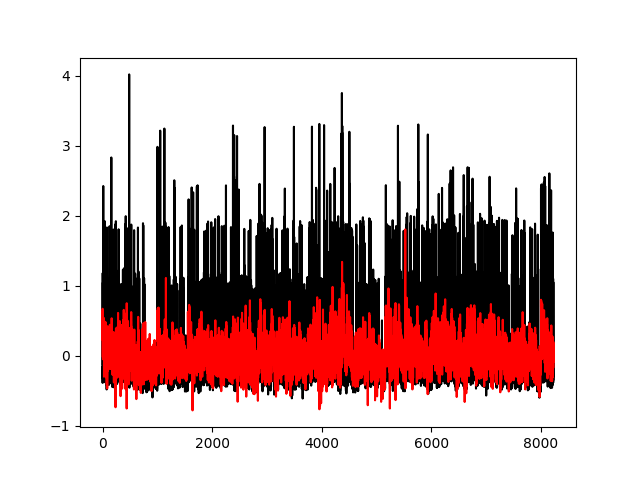

In [55]:
fig, ax = plt.subplots()
ax.plot(test_y[:,0], c='black')
ax.plot(test_predic[:,0], c='red')